Media retornos (log): 0.0005911722338864076
Desv. est. retornos (log): 0.012064277423048766
95% de confianza que el precio cierre en 30 días estará entre 617.60 y 798.06
El valor esperado del precio de cierre en 30 días es 702.40
El VaR al 95% es 59.18


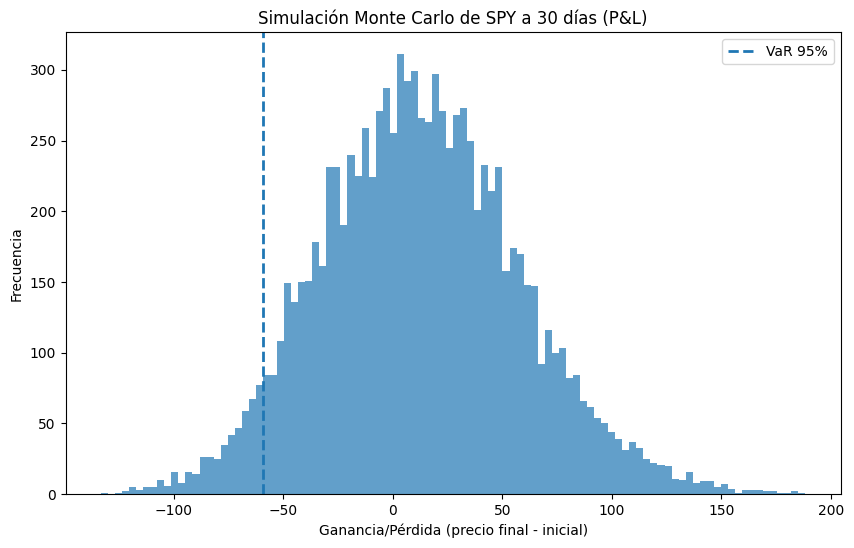

In [ ]:
# %%
# imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# %%
# bajar datos
today = pd.Timestamp.today()
start = today - pd.Timedelta(days=365)
start_date = start.strftime('%Y-%m-%d')
start_date

# %%
symbol = 'SPY'  # ticker
df_stock = yf.download(
    symbol,
    start=start_date,
    end=today.strftime('%Y-%m-%d')
)[['Close']].copy()
df_stock

# %%
# calcular los retornos logaritmicos diarios
# lo utilizamos para facilitar la simulacion y estadistica
# para generar simetria en la distribucion normal
df_stock["returns"] = np.log(df_stock["Close"] / df_stock["Close"].shift(1))
df_stock

# %%
# media y desviacion estandard
means_returns = df_stock["returns"].mean()
std_returns = df_stock["returns"].std()

means_returns, std_returns

# %%
# simulacion de monte carlo
def montecarlo_simulation(df_prices, n_simulations=10000, n_days=30, mu=0, sigma=1):
    # incializar la matriz de procesos simulados (10000x30), con ceros
    simulated_prices = np.zeros((n_simulations, n_days))

    # El primer precio es el ultimo precio conocido
    initial_price = df_prices.iloc[-1]

    # asignar el precio inicial a todas las simulaciones
    simulated_prices[:, 0] = initial_price

    # simular los precios para cada dia y cada simulacion
    for i in range(1, n_days):
        simulated_prices[:, i] = simulated_prices[:, i-1] * (
            1 + np.random.normal(mu, sigma, n_simulations)
        )

    return simulated_prices

# %%
# ejecutar simulacion de 10000 caminos de 30 dias
simulated_prices = montecarlo_simulation(
    df_stock["Close"],
    n_simulations=10000,
    n_days=30,
    mu=means_returns,
    sigma=std_returns
)
simulated_prices

# %%
# percentiles y rangos de confianza
percentil_2_5 = np.percentile(simulated_prices[:, -1], 2.5)
percentil_97_5 = np.percentile(simulated_prices[:, -1], 97.5)

percentil_2_5, percentil_97_5

# %%
print(
    f"95% de confianza que el precio cierre en 30 dias estara entre "
    f"{percentil_2_5:.2f} y {percentil_97_5:.2f}"
)

# %%
# valor esperado la media de los precios simulados al final del periodo
expected_value = np.mean(simulated_prices[:, -1])
print(
    f"El valor esperado del precio de cierre en 30 dias es {expected_value:.2f}"
)

# %%
# calculo de VAR
confincence_interval = 0.95
simulated_prices_flat = simulated_prices[:, 1:].flatten()
simulated_prices

# %%
VaR = -np.percentile(
    simulated_prices_flat,
    100 * (1 - confincence_interval)
)
print(f"El VaR al {confincence_interval*100:.0f} es {VaR:.2f}")

# %%
# mostrar grafico
plt.figure(figsize=(10, 6))
plt.hist(simulated_prices_flat, bins=100, color='blue', alpha=0.7)
plt.title(f'Simulacion de montecarlo de {symbol} para 30 dias')
plt.xlabel('Scenario Gain/Loss')
plt.ylabel('Frecuencia')
plt.axvline(
    -VaR,
    color='r',
    linestyle='dashed',
    linewidth=2,
    label=f'VaR at {confincence_interval} intervalo de confianza'
)
plt.legend()
plt.show()

# %%
# interpretacion
# con un 95% de confianza el valor nos indica que en los proximos 30 dias
# no perderemos mas de 644.44 en preciosn de cierre
